In [1]:
#import libraries
import pandas as pd
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)


c:\Users\Charlie\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df_US = df[df['job_country'] == 'United States']

In [ ]:
df_skills = df_US.explode('job_skills')
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count').sort_values(by='skill_count', ascending=False)

In [ ]:
job_titles = df_skills_count['job_title_short'].unique().tolist()[:3]

In [ ]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='Count of jobs')

df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_perc['skill_percent'] = (df_skills_perc['skill_count'] / df_skills_perc['Count of jobs']) * 100
df_skills_perc

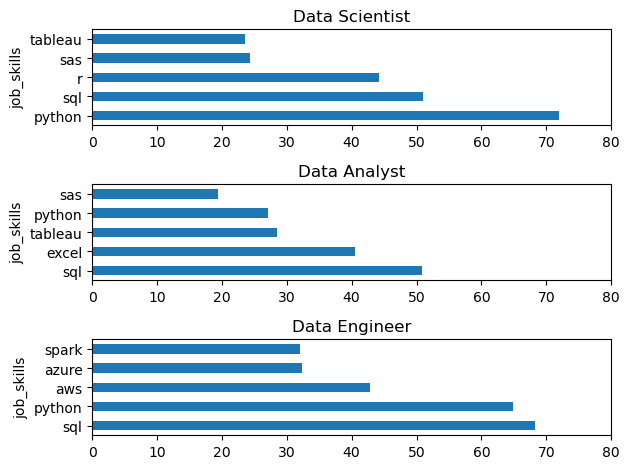

In [53]:
fig, ax = plt.subplots(len(job_titles),1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_percent', ax=ax[i], title=job_title)
    ax[i].legend().set_visible(False)
    fig.tight_layout()
    ax[i].set_xlim(0,80)